# Gráficos — Operação (LED-39)

Consultas de [`analytics/04_consultas_operacao.sql`](04_consultas_operacao.sql), plotadas
para apoiar os slides de apresentação (LED-44). Conecta direto no `warehouse.duckdb` e
consulta só o modelo final (`fato_corrida` + `dim_hora`).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect('../warehouse.duckdb', read_only=True)

# Paleta categórica validada (ordem fixa, não ciclada) - ver skill de dataviz do projeto
BLUE = '#2a78d6'    # baseline / corridas normais
ORANGE = '#eb6834'  # destaque / viagens fora do padrão
TEXT = '#0b0b0b'
MUTED = '#52514e'
GRID = '#e5e4e0'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': MUTED,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.size': 11,
})

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def milhar(x, _=None):
    return f'{int(x):,}'.replace(',', '.')

## Distância

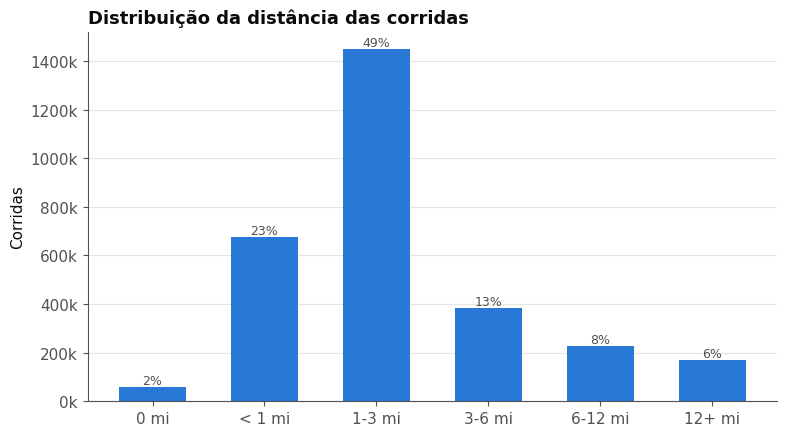

In [2]:
df = con.execute('''
    SELECT
        CASE
            WHEN trip_distance = 0    THEN '0: 0 mi'
            WHEN trip_distance < 1    THEN '1: < 1 mi'
            WHEN trip_distance < 3    THEN '2: 1-3 mi'
            WHEN trip_distance < 6    THEN '3: 3-6 mi'
            WHEN trip_distance < 12   THEN '4: 6-12 mi'
            ELSE '5: 12+ mi'
        END AS faixa_distancia,
        COUNT(*) AS qtd_corridas
    FROM fato_corrida
    GROUP BY faixa_distancia
    ORDER BY faixa_distancia
''').fetchdf()
total = df['qtd_corridas'].sum()
rotulos = ['0 mi', '< 1 mi', '1-3 mi', '3-6 mi', '6-12 mi', '12+ mi']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(rotulos, df['qtd_corridas'], color=BLUE, width=0.6)
ax.set_title('Distribuição da distância das corridas', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b, pct in zip(bars, df['qtd_corridas'] / total * 100):
    ax.annotate(f'{pct:.0f}%', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Quase metade das corridas (49%) fica entre 1 e 3 milhas — deslocamento curto típico de Manhattan; viagens de 12+ milhas são só 5,7% do total, mas puxam bastante o ticket médio (ver notebook Financeiro).

## Velocidade aproximada

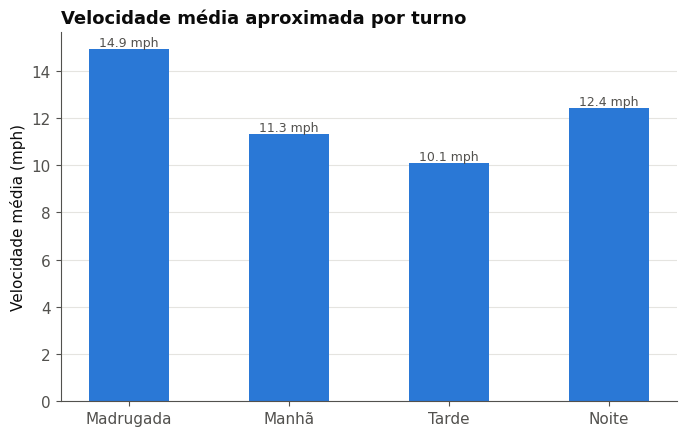

In [3]:
df = con.execute('''
    SELECT h.turno, COUNT(*) AS qtd_corridas,
           ROUND(AVG(f.trip_distance / (f.trip_duration_minutes / 60.0)), 1) AS velocidade_media_mph
    FROM fato_corrida f
    JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    WHERE f.trip_distance > 0 AND f.trip_duration_minutes > 0 AND NOT f.is_speed_outlier
    GROUP BY h.turno
''').fetchdf()
ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
df['turno'] = pd.Categorical(df['turno'], categories=ordem, ordered=True)
df = df.sort_values('turno')

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(df['turno'], df['velocidade_media_mph'], color=BLUE, width=0.5)
ax.set_title('Velocidade média aproximada por turno', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Velocidade média (mph)')
style_ax(ax)
for b in bars:
    ax.annotate(f'{b.get_height():.1f} mph', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Madrugada é quase 50% mais rápida que a tarde (14,9mph vs. 10,1mph) — o mesmo padrão de trânsito que já aparecia na duração média por turno (notebook Tempo), só que agora expresso diretamente em velocidade.

## Eficiência por faixa de distância

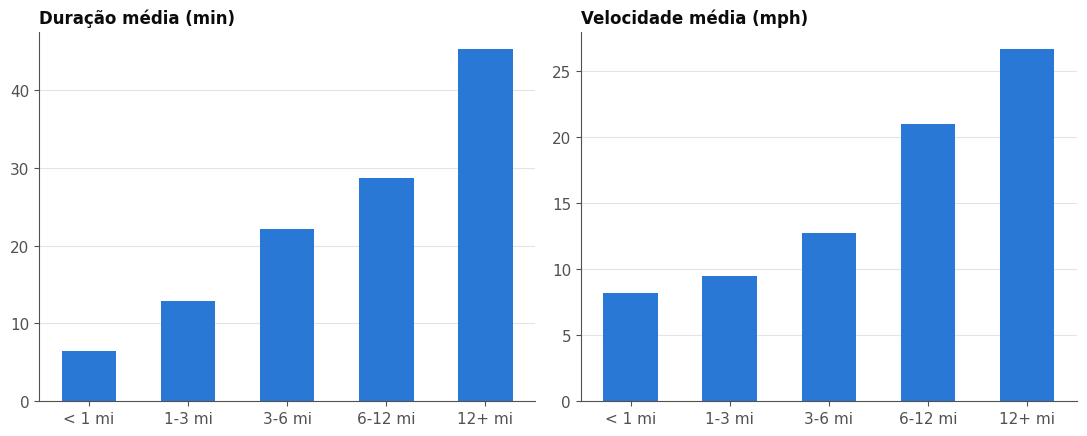

In [4]:
df = con.execute('''
    SELECT
        CASE
            WHEN trip_distance < 1  THEN '1: < 1 mi'
            WHEN trip_distance < 3  THEN '2: 1-3 mi'
            WHEN trip_distance < 6  THEN '3: 3-6 mi'
            WHEN trip_distance < 12 THEN '4: 6-12 mi'
            ELSE '5: 12+ mi'
        END AS faixa_distancia,
        COUNT(*) AS qtd_corridas,
        ROUND(AVG(trip_duration_minutes), 1) AS duracao_media_min,
        ROUND(AVG(trip_distance / (trip_duration_minutes / 60.0)), 1) AS velocidade_media_mph
    FROM fato_corrida
    WHERE trip_distance > 0 AND trip_duration_minutes > 0 AND NOT is_speed_outlier
    GROUP BY faixa_distancia
    ORDER BY faixa_distancia
''').fetchdf()
rotulos = ['< 1 mi', '1-3 mi', '3-6 mi', '6-12 mi', '12+ mi']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(rotulos, df['duracao_media_min'], color=BLUE, width=0.55)
axes[0].set_title('Duração média (min)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[0])

axes[1].bar(rotulos, df['velocidade_media_mph'], color=BLUE, width=0.55)
axes[1].set_title('Velocidade média (mph)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1])

plt.tight_layout()
plt.show()

Corridas curtas são desproporcionalmente lentas (< 1mi roda a 8,2mph, menos de um terço da velocidade das corridas de 12+ mi a 26,6mph) — sinal de que viagens curtas ficam presas em trânsito de superfície/semáforos, enquanto as longas aproveitam trechos de via expressa.

## Ocupação

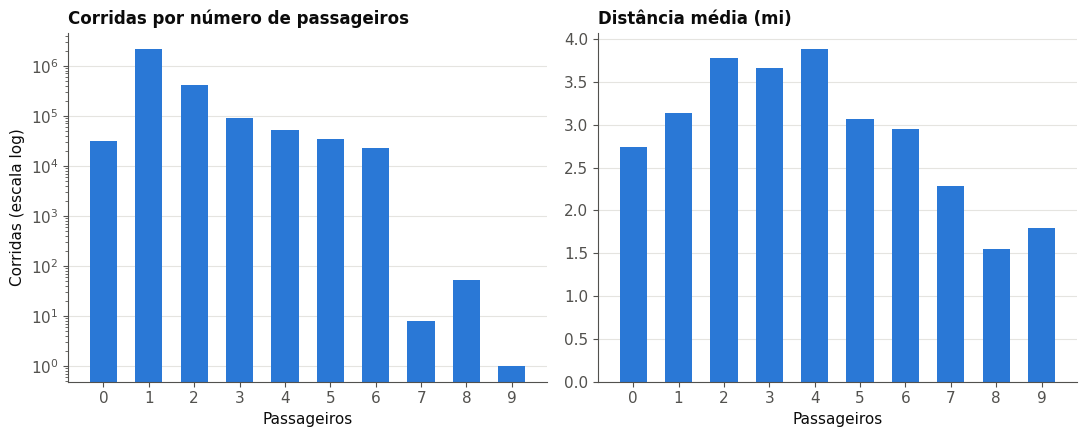

In [5]:
df = con.execute('''
    SELECT passenger_count, COUNT(*) AS qtd_corridas, ROUND(AVG(trip_distance), 2) AS distancia_media_mi
    FROM fato_corrida
    WHERE passenger_count IS NOT NULL
    GROUP BY passenger_count
    ORDER BY passenger_count
''').fetchdf()
df['passenger_count'] = df['passenger_count'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(df['passenger_count'].astype(str), df['qtd_corridas'], color=BLUE, width=0.6)
axes[0].set_title('Corridas por número de passageiros', loc='left', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passageiros')
axes[0].set_yscale('log')
axes[0].set_ylabel('Corridas (escala log)')
style_ax(axes[0])

axes[1].bar(df['passenger_count'].astype(str), df['distancia_media_mi'], color=BLUE, width=0.6)
axes[1].set_title('Distância média (mi)', loc='left', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passageiros')
style_ax(axes[1])

plt.tight_layout()
plt.show()

Corrida solo (1 passageiro) é o padrão esmagador — 73,8% do total. Grupos de 2 a 4 passageiros viajam, em média, mais longe (3,7-3,9mi) que corridas solo (3,1mi), consistente com uso compartilhado para trajetos maiores (aeroporto, passeio) em vez de deslocamento individual do dia a dia.

## Viagens fora do padrão

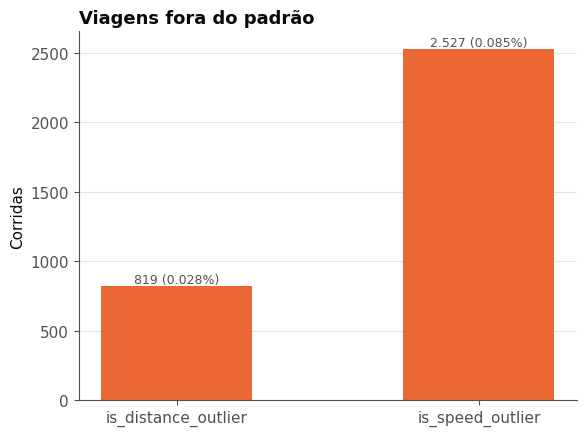

In [6]:
df = con.execute('''
    SELECT
        SUM(CASE WHEN is_distance_outlier THEN 1 ELSE 0 END) AS qtd_distance_outlier,
        SUM(CASE WHEN is_speed_outlier THEN 1 ELSE 0 END) AS qtd_speed_outlier,
        COUNT(*) AS total_corridas,
        ROUND(100.0 * SUM(CASE WHEN is_distance_outlier THEN 1 ELSE 0 END) / COUNT(*), 3) AS pct_distance_outlier,
        ROUND(100.0 * SUM(CASE WHEN is_speed_outlier THEN 1 ELSE 0 END) / COUNT(*), 3) AS pct_speed_outlier
    FROM fato_corrida
''').fetchdf()

rotulos = ['is_distance_outlier', 'is_speed_outlier']
valores = [df['qtd_distance_outlier'].iloc[0], df['qtd_speed_outlier'].iloc[0]]
pcts = [df['pct_distance_outlier'].iloc[0], df['pct_speed_outlier'].iloc[0]]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(rotulos, valores, color=ORANGE, width=0.5)
ax.set_title('Viagens fora do padrão', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
style_ax(ax)
for b, v, pct in zip(bars, valores, pcts):
    ax.annotate(f'{milhar(v)} ({pct:.3f}%)', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

As duas flags são raríssimas (819 e 2.527 corridas, bem abaixo de 0,1% cada) — erro de captura de GPS/taxímetro é exceção, não padrão sistemático na base.

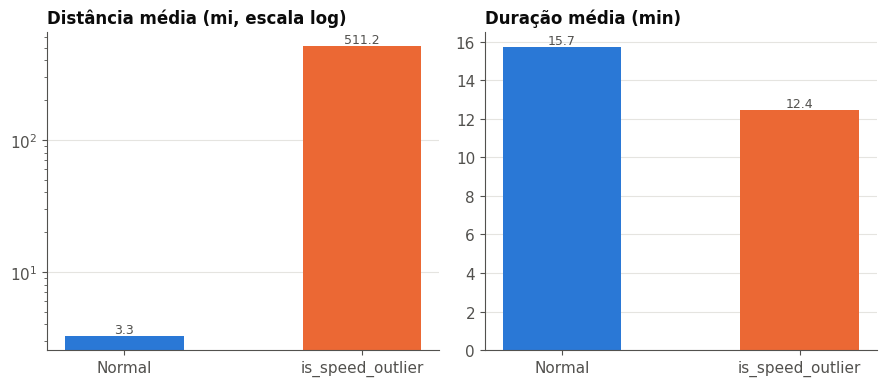

In [7]:
df = con.execute('''
    SELECT is_speed_outlier, COUNT(*) AS qtd_corridas,
           ROUND(AVG(trip_distance), 2) AS distancia_media_mi,
           ROUND(AVG(trip_duration_minutes), 2) AS duracao_media_min
    FROM fato_corrida
    WHERE trip_distance > 0 AND trip_duration_minutes > 0
    GROUP BY is_speed_outlier
''').fetchdf()
df['label'] = df['is_speed_outlier'].map({False: 'Normal', True: 'is_speed_outlier'})
cores = [BLUE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(df['label'], df['distancia_media_mi'], color=cores, width=0.5)
axes[0].set_title('Distância média (mi, escala log)', loc='left', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
style_ax(axes[0])
for i, v in enumerate(df['distancia_media_mi']):
    axes[0].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom', fontsize=9, color=MUTED)

axes[1].bar(df['label'], df['duracao_media_min'], color=cores, width=0.5)
axes[1].set_title('Duração média (min)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1])
for i, v in enumerate(df['duracao_media_min']):
    axes[1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom', fontsize=9, color=MUTED)

plt.tight_layout()
plt.show()

A assinatura confirma o diagnóstico de `docs/regras_limpeza.md` (item 5): distância média de 511mi em `is_speed_outlier` com duração de apenas 12,5min — corrida curta com distância absurda, erro de GPS/taxímetro, não velocidade real. Nada perto do padrão de 3,3mi/15,7min das corridas normais.